In [38]:
#import labraries
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
import lightgbm as ltb

In [5]:
dataset = pd.read_csv('supplement.csv')

In [6]:
dataset

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52
...,...,...,...,...,...,...,...,...,...,...
188335,T1188336,149,S2,L3,R2,2019-05-31,1,Yes,51,37272.00
188336,T1188337,153,S4,L2,R1,2019-05-31,1,No,90,54572.64
188337,T1188338,154,S1,L3,R2,2019-05-31,1,No,56,31624.56
188338,T1188339,155,S3,L1,R2,2019-05-31,1,Yes,70,49162.41


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ID             188340 non-null  object 
 1   Store_id       188340 non-null  int64  
 2   Store_Type     188340 non-null  object 
 3   Location_Type  188340 non-null  object 
 4   Region_Code    188340 non-null  object 
 5   Date           188340 non-null  object 
 6   Holiday        188340 non-null  int64  
 7   Discount       188340 non-null  object 
 8   #Order         188340 non-null  int64  
 9   Sales          188340 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 14.4+ MB


In [8]:
dataset.isnull().sum()

ID               0
Store_id         0
Store_Type       0
Location_Type    0
Region_Code      0
Date             0
Holiday          0
Discount         0
#Order           0
Sales            0
dtype: int64

In [9]:
dataset.isnull()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
188335,False,False,False,False,False,False,False,False,False,False
188336,False,False,False,False,False,False,False,False,False,False
188337,False,False,False,False,False,False,False,False,False,False
188338,False,False,False,False,False,False,False,False,False,False


In [10]:
dataset.describe()

,Store_id,Holiday,#Order,Sales
count,188340.000000,188340.000000,188340.000000,188340.000000
mean,183.000000,0.131783,68.205692,42784.327982
std,105.366308,0.338256,30.467415,18456.708302
min,1.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,48.000000,30426.000000
50%,183.000000,0.000000,63.000000,39678.000000
75%,274.000000,0.000000,82.000000,51909.000000
max,365.000000,1.000000,371.000000,247215.000000


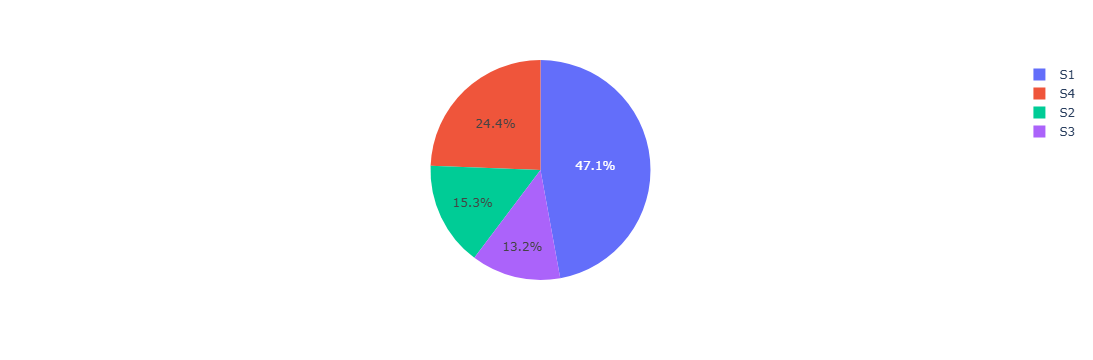

In [17]:
pie = dataset["Store_Type"].value_counts()
store = pie.index
orders = pie.values
fig = px.pie(values = orders, names = store)
fig.show()

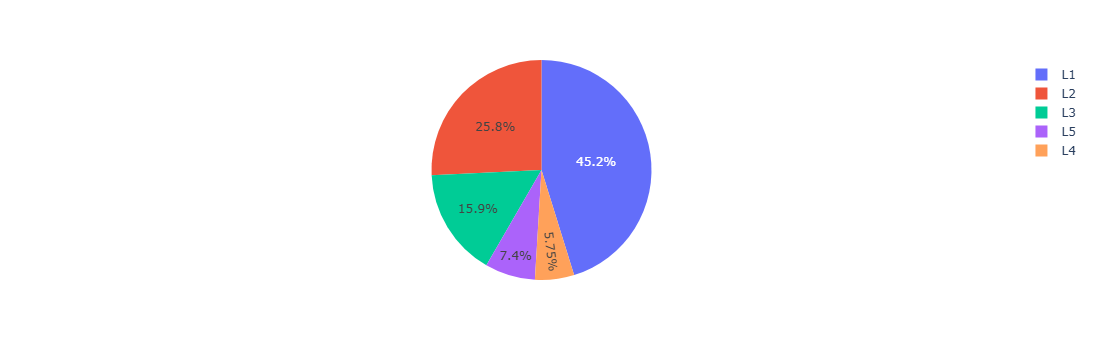

In [21]:
pie1 = dataset["Location_Type"].value_counts()
location = pie1.index
orders = pie1.values
fig = px.pie(values = orders, names = location)
fig.show()

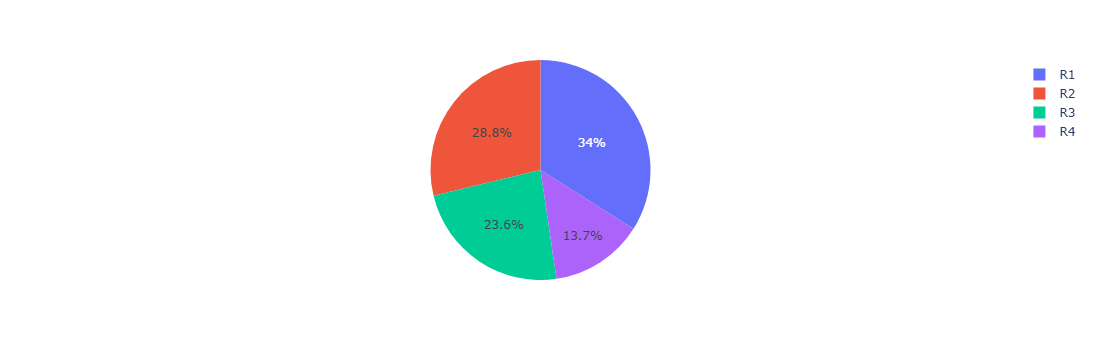

In [22]:
pie2 = dataset["Region_Code"].value_counts()
region = pie2.index
orders = pie2.values
fig = px.pie(values = orders, names = region)
fig.show()

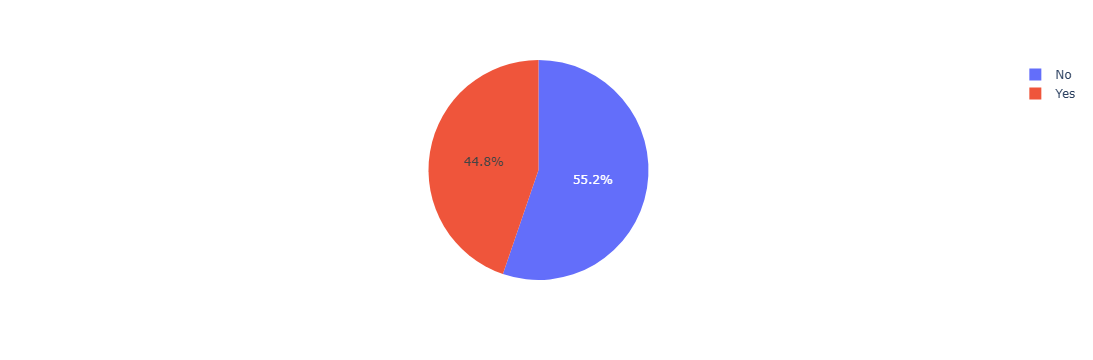

In [23]:
pie3 = dataset["Discount"].value_counts()
discount = pie3.index
orders = pie3.values
fig = px.pie(values = orders, names = discount)
fig.show()

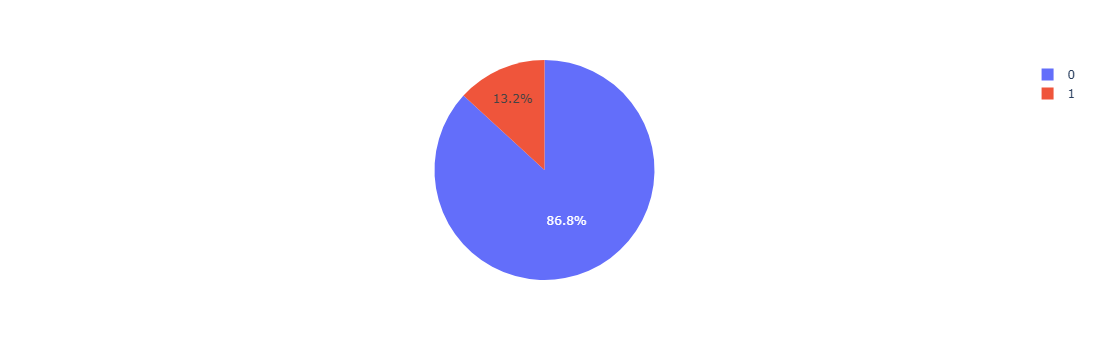

In [24]:
pie4 = dataset["Holiday"].value_counts()
holiday = pie4.index
orders = pie4.values
fig = px.pie(values = orders, names = holiday)
fig.show()

In [25]:
dataset["Discount"] = dataset["Discount"].map({"No": 0, "Yes": 1})

In [26]:
dataset

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,1,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,1,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,1,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,1,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,1,62,45614.52
...,...,...,...,...,...,...,...,...,...,...
188335,T1188336,149,S2,L3,R2,2019-05-31,1,1,51,37272.00
188336,T1188337,153,S4,L2,R1,2019-05-31,1,0,90,54572.64
188337,T1188338,154,S1,L3,R2,2019-05-31,1,0,56,31624.56
188338,T1188339,155,S3,L1,R2,2019-05-31,1,1,70,49162.41


In [27]:
dataset["Store_Type"] = dataset["Store_Type"].map({"S1": 1, "S2": 2, "S3": 3, "S4":4})

In [28]:
dataset

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,1,L3,R1,2018-01-01,1,1,9,7011.84
1,T1000002,253,4,L2,R1,2018-01-01,1,1,60,51789.12
2,T1000003,252,3,L2,R1,2018-01-01,1,1,42,36868.20
3,T1000004,251,2,L3,R1,2018-01-01,1,1,23,19715.16
4,T1000005,250,2,L3,R4,2018-01-01,1,1,62,45614.52
...,...,...,...,...,...,...,...,...,...,...
188335,T1188336,149,2,L3,R2,2019-05-31,1,1,51,37272.00
188336,T1188337,153,4,L2,R1,2019-05-31,1,0,90,54572.64
188337,T1188338,154,1,L3,R2,2019-05-31,1,0,56,31624.56
188338,T1188339,155,3,L1,R2,2019-05-31,1,1,70,49162.41


In [29]:
dataset["Location_Type"] = dataset["Location_Type"].map({"L1": 1, "L2": 2, "L3": 3, "L4":4, "L5":5})

In [30]:
dataset

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,1,3,R1,2018-01-01,1,1,9,7011.84
1,T1000002,253,4,2,R1,2018-01-01,1,1,60,51789.12
2,T1000003,252,3,2,R1,2018-01-01,1,1,42,36868.20
3,T1000004,251,2,3,R1,2018-01-01,1,1,23,19715.16
4,T1000005,250,2,3,R4,2018-01-01,1,1,62,45614.52
...,...,...,...,...,...,...,...,...,...,...
188335,T1188336,149,2,3,R2,2019-05-31,1,1,51,37272.00
188336,T1188337,153,4,2,R1,2019-05-31,1,0,90,54572.64
188337,T1188338,154,1,3,R2,2019-05-31,1,0,56,31624.56
188338,T1188339,155,3,1,R2,2019-05-31,1,1,70,49162.41


In [31]:
X = np.array(dataset[["Store_Type", "Location_Type", "Holiday", "Discount"]])
y = np.array(dataset["#Order"])

In [32]:
X

array([[1, 3, 1, 1],
       [4, 2, 1, 1],
       [3, 2, 1, 1],
       ...,
       [1, 3, 1, 0],
       [3, 1, 1, 1],
       [2, 1, 1, 0]], shape=(188340, 4))

In [33]:
y

array([ 9, 60, 42, ..., 56, 70, 47], shape=(188340,))

In [35]:
#building the ml model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [36]:
len(X_train)

141255

In [40]:
model = ltb.LGBMRegressor()

In [41]:
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15
[LightGBM] [Info] Number of data points in the train set: 141255, number of used features: 4
[LightGBM] [Info] Start training from score 68.153764


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [42]:
y_pred = model.predict(X_test)

C:\Users\Arka Chowdhury\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



In [43]:
y_pred

array([47.37993829, 97.01476762, 66.54836898, ..., 45.01752051,
       66.54836898, 45.01752051], shape=(47085,))

In [44]:
y_test

array([ 54, 111,  59, ...,  30,  52,  38], shape=(47085,))

In [ ]:
data = pd.DataFrame(data